# Benchmark

---

## Setup

In [1]:
import os
dir = os.path.abspath('')  # directory of notebookimport numpy as np
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
from src.FoKL.fokl_to_pyomo import fokl_to_pyomo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae

In [18]:
modelname = "tclab_residual"

In [19]:
alpha = 0.00016  # watts / (units P1 * percent U1)
P1 = 200  # P1 units

# # Via inv_CpH, inv_CpS:
# Ua  = 0.05405229846011348
# Ub  = 0.05294170189601992
# CpH = 6.055477666513158
# CpS = 1.004922603766054

# Via CpH, CpS:
Ua  = 0.052384291033157684
Ub  = 0.060521133829919416
CpH = 5.568800661406845
CpS = 1.2773885658179458

In [20]:
tvec = [0, 50, 150, 450, 550, 1000]

def r(t):  # setpoint/reference
    return np.interp(t, tvec, [0, 0, 35, 35, 10, 10])

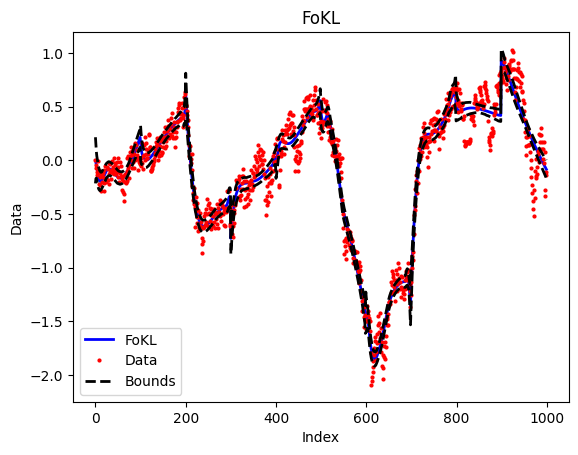

In [21]:
GP = FoKLRoutines.load(os.path.join(dir, "models", modelname))
_ = GP.coverage3(plot=True)

## Pyomo - Average of 1000 draws

In [22]:
m = pyo.ConcreteModel("TCLab")
m.t = dae.ContinuousSet(bounds=(tvec[0], tvec[-1]))

m.Th1 = pyo.Var(m.t, bounds=GP.minmax[0])  # un-corrected
m.Ts1 = pyo.Var(m.t, bounds=GP.minmax[1])  # un-corrected
m.u1 = pyo.Var(m.t, bounds=GP.minmax[2])
m.Ts1_GP = pyo.Var(m.t)  # Ts1 integrated with residual
m.R = pyo.Var(m.t)  # residual

m.dTh1 = dae.DerivativeVar(m.Th1)
m.dTs1 = dae.DerivativeVar(m.Ts1)

m.Th1[0].fix(0.0)  # initial conditions
m.Ts1[0].fix(0.0)
m.u1[0].fix(0.0)
m.R[0].fix(0.0)
m.Ts1_GP[0].fix(0.0)

fokl_to_pyomo(GP, [m.Th1, m.Ts1, m.u1], m.R, m, m.t)
m.GP0[0].deactivate()  # disable constraint at t0 since (Th1, Ts1, u1, R) = 0

@m.Constraint(m.t)  # first differential equation
def heater1(m, t):
    return (
        CpH * m.dTh1[t]
        == -Ua * m.Th1[t] + Ub * (m.Ts1[t] - m.Th1[t]) + alpha * P1 * m.u1[t]
    )

@m.Constraint(m.t)  # second differential equation
def sensor1(m, t):
    return CpS * m.dTs1[t] == Ub * (m.Th1[t] - m.Ts1[t])

@m.Constraint(m.t)  # second state, with residual correction
def sensor1_residual(m, t):
    return m.Ts1_GP[t] == m.Ts1[t] + m.R[t]

@m.Integral(m.t)  # integral of squared error
def ise(m, t):
    return (r(t) - m.Ts1_GP[t]) ** 2

m.du1 = dae.DerivativeVar(m.u1)
@m.Integral(m.t)  # penalty term meant to smooth m.u1
def sum_du1(m, t):
    return m.du1[t] ** 2

@m.Objective(sense=pyo.minimize)  # objective function
def objective(m):
    return m.ise + 0.5 * m.sum_du1

pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)
pyo.SolverFactory('ipopt').solve(m, tee=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 4203, 'Number of variables': 4803, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'Ipopt 3.13.2\\x3a Optimal Solution Found', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 3.0422487258911133}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

### Results

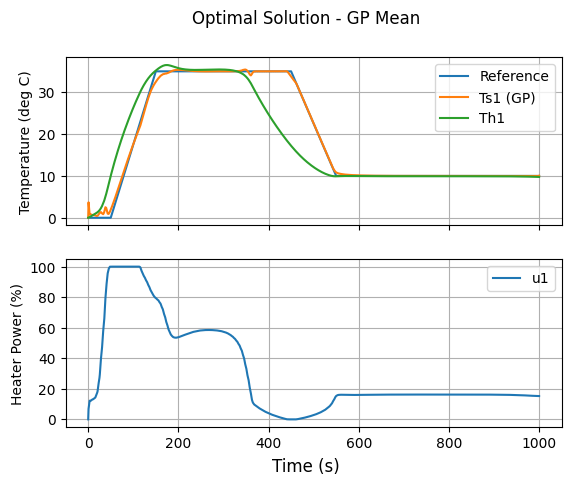

In [23]:
fig, ax = plt.subplots(2, sharex=True)
fig.suptitle("Optimal Solution - GP Mean")
fig.supxlabel("Time (s)")
ax[0].set_ylabel("Temperature (deg C)")
ax[1].set_ylabel("Heater Power (%)")

ax[0].plot(tvec, r(tvec), label="Reference")
ax[0].plot(m.t, m.Ts1_GP[:](), label="Ts1 (GP)")
ax[0].plot(m.t, m.Th1[:](), label="Th1")

ax[1].plot(m.t, m.u1[:](), label="u1")

for i in range(2):
    ax[i].legend()
    ax[i].grid()

### Save Results

In [ ]:
solution = pd.DataFrame()

solution["Time"] = m.t
solution["Q1"] = m.u1[:]()

solution.to_csv(os.path.join(dir, "data", "solution_averageDraws_0o5du1.csv"))

## Pyomo - Scenarios

NOTE FOR DEBUGGING
- ```CASE = 1, scenarios = 1``` should, in theory, yield same solution as above "Average of Draws" solution; failure to do so (and memory reallocation) implies a bug in the Pyomo model

In [7]:
CASE = 1
scenarios = 1

In [39]:
m = pyo.ConcreteModel("TCLab")
m.t = dae.ContinuousSet(bounds=(tvec[0], tvec[-1]))
m.s = pyo.Set(initialize=range(scenarios))  # scenarios

m.Th1 = pyo.Var(m.t, m.s, bounds=GP.minmax[0])  # un-corrected
m.Ts1 = pyo.Var(m.t, m.s, bounds=GP.minmax[1])  # un-corrected
m.u1 = pyo.Var(m.t, bounds=GP.minmax[2])
m.Ts1_GP = pyo.Var(m.t, m.s)  # Ts1 integrated with residual
m.R = pyo.Var(m.t, m.s)  # residual

m.dTh1 = dae.DerivativeVar(m.Th1, wrt=m.t)
m.dTs1 = dae.DerivativeVar(m.Ts1, wrt=m.t)

m.u1[0].fix(0.0)  # initial conditions
for s in m.s:
    m.Th1[0, s].fix(0.0)
    m.Ts1[0, s].fix(0.0)
    m.R[0, s].fix(0.0)
    m.Ts1_GP[0, s].fix(0.0)

pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)  # DEBUG: SEEMS NEEDED HERE FOR m.GP0_y TO INDEX m.t
fokl_to_pyomo(GP, [m.Th1, m.Ts1, m.u1], m.R, m, m.t, m.s)
for s in m.s:
    m.GP0[0, s].deactivate()  # disable constraint at t0 since (Th1, Ts1, u1, R) = 0

# FOR DEBUGGING, ASSIGN ALL SCENARIOS EQUAL TO AVERAGE OF DRAWS:
betas_avg = np.mean(GP.betas, axis=0)
for s in m.s:
    for term in m.GP0_terms:
        m.GP0_beta[s, term] = betas_avg[term]

@m.Constraint(m.t, m.s)  # first differential equation
def heater1(m, t, s):
    return (
        CpH * m.dTh1[t, s]
        == -Ua * m.Th1[t, s] + Ub * (m.Ts1[t, s] - m.Th1[t, s]) + alpha * P1 * m.u1[t]
    )

@m.Constraint(m.t, m.s)  # second differential equation
def sensor1(m, t, s):
    return CpS * m.dTs1[t, s] == Ub * (m.Th1[t, s] - m.Ts1[t, s])

@m.Constraint(m.t, m.s)  # second state, with residual correction
def sensor1_residual(m, t, s):
    return m.Ts1_GP[t, s] == m.Ts1[t, s] + m.R[t, s]

@m.Integral(m.t, m.s, wrt=m.t)  # integral of squared error
def ise(m, t, s):
    return (r(t) - m.Ts1_GP[t, s]) ** 2

m.du1 = dae.DerivativeVar(m.u1)
@m.Integral(m.t)  # penalty term meant to smooth m.u1
def sum_du1(m, t):
    return m.du1[t] ** 2

# =====================================================================================
# CASE 1 - MINIMZE AVERAGE ERROR ACROSS ALL SCENARIOS:

if CASE == 1:

    @m.Objective(sense=pyo.minimize)  # objective function
    def objective(m):
        return sum(m.ise[s] for s in m.s) / len(m.s) + 0.5 * m.sum_du1

# =====================================================================================
# CASE 2 - MINIMIZE WORST CASE SCENARIO:

elif CASE == 2:

    m.z = pyo.Var(domain=pyo.NonNegativeReals)  # dummy variable to minimize in objective

    @m.Constraint(m.s)
    def error_threshold(m, s):
        return m.ise[s] <= m.z

    @m.Objective(sense=pyo.minimize)
    def objective(m):
        return m.z + 0.05 * m.sum_du1

# =====================================================================================

# pyo.TransformationFactory('dae.collocation').apply_to(m, nfe=200, wrt=m.t)
# pyo.TransformationFactory('dae.finite_difference').apply_to(m, nfe=10, wrt=m.t)

solver = pyo.SolverFactory('ipopt')
solver.options['linear_solver'] = 'ma57'
solver.solve(m, tee=True)

Ipopt 3.13.2: linear_solver=ma57


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        compu

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 3603, 'Number of variables': 4803, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'Ipopt 3.13.2\\x3a Optimal Solution Found', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.9348406791687012}], 'Solution': [OrderedDict([('number of solutions', 0), ('number of solutions displayed', 0)])]}

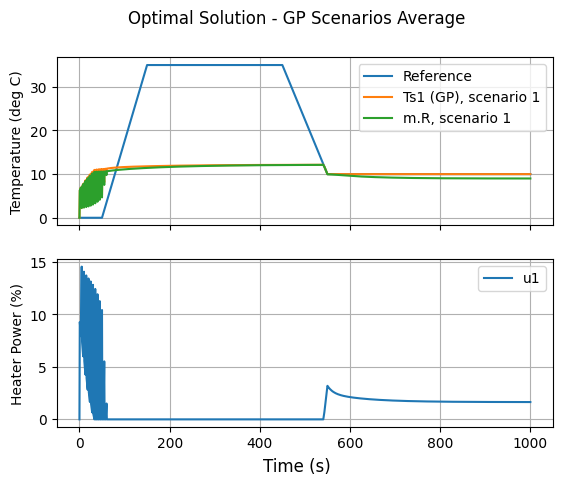

In [42]:
TYPE = {1: "Average", 2: "Worst Case"}

fig, ax = plt.subplots(2, sharex=True)
fig.suptitle(f"Optimal Solution - GP Scenarios {TYPE[CASE]}")
fig.supxlabel("Time (s)")
ax[0].set_ylabel("Temperature (deg C)")
ax[1].set_ylabel("Heater Power (%)")

ax[0].plot(tvec, r(tvec), label="Reference")
for s in m.s:
    ax[0].plot(m.t, m.Ts1_GP[:, s](), label=f"Ts1 (GP), scenario {s + 1}")  # , linewidth=10 / (s + 1))
    # ax[0].plot(m.t.data()[1::], m.GP0_y[:, s]()[1::], label=f"m.GP0_y, scenario {s + 1}")
    ax[0].plot(m.t, m.R[:, s](), label=f"m.R, scenario {s + 1}")
    # ax[0].plot(m.t, m.Ts1[:, s](), label=f"m.Ts1, scenario {s + 1}", linewidth=5 / (s + 1))
    # ax[0].plot(m.t, m.Th1[:, s](), label=f"m.Th1, scenario {s + 1}", linewidth=5 / (s + 1))

ax[1].plot(m.t, m.u1[:](), label="u1")

for i in range(2):
    ax[i].legend()
    ax[i].grid()

c:\Users\jakep\ESMS\dev\tclab\examples\pyomo_tclab\..\..\src\FoKL\FoKLRoutines.py:290: UserWarning: 'inputs' was transposed. Ignore if more datapoints than input variables, else set 'AutoTranspose=False' to disable.
  warnings.warn("'inputs' was transposed. Ignore if more datapoints than input variables, else set "


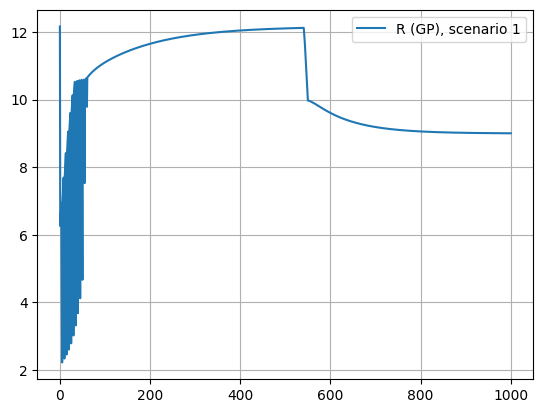

In [43]:
for s in m.s:
    plt.plot(m.t, GP.evaluate([m.Th1[:, s](), m.Ts1[:, s](), m.u1[:]()], betas=m.GP0_beta[s, :](), clean=True), label=f"R (GP), scenario {s + 1}")
plt.legend()
plt.grid()

In [ ]:
solution = pd.DataFrame()

solution["Time"] = m.t
solution["Q1"] = m.u1[:]()

if CASE == 1:
    solution.to_csv(os.path.join(dir, "data", "solution_scenariosCase1_0o005du1.csv"))
elif CASE == 2:
    solution.to_csv(os.path.join(dir, "data", "solution_scenariosCase2_0o005du1.csv"))